In [1]:
import torch
from torch import nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader, random_split
from transformers import WhisperForAudioClassification, WhisperProcessor
import os
import re
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix, recall_score, precision_score, f1_score, accuracy_score, classification_report, balanced_accuracy_score
import seaborn as sns
import warnings
warnings.filterwarnings("ignore")
import time
from tqdm import tqdm
import librosa
import random

c:\Users\top\Desktop\shemo_env\shemo_env\lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
if torch.cuda.is_available():
  device = 'cuda'
else:
  device = 'cpu'

device

'cuda'

In [3]:
# Defining a function to set or change the seed for random number generation at each step.

def reset_seed(seed):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    if torch.cuda.is_available:
        torch.cuda.manual_seed(seed)
        torch.cuda.manual_seed_all(seed)
        torch.backends.cudnn.deterministic = True
        torch.backends.cudnn.benchmark = False

In [4]:
whisper_tiny_processor = WhisperProcessor.from_pretrained('whisper_tiny')

In [5]:
reset_seed(42)
emo2num = {
    'H' : 0,
    'N' : 1,
    'S' : 2,
    'A' : 3,
    'W' : 4
}

num2emo = {
    0 : 'Happy',
    1 : 'Neutral',
    2 : 'Sad',
    3 : 'Anger',
    4 : 'Wonder'
}


audios = []
sample_rates = []
emotions = []
labels = []
features = []
genders = []
gender_labels = []

pattern = r'^...(.)'

for root, folders, files in os.walk('shemo'):
    for filename in files:
        file_path = os.path.join(root, filename)
        audio_data, sr = librosa.load(file_path, sr=16000)
        
        input_features = whisper_tiny_processor(audio_data, sampling_rate=sr, return_tensors="pt").input_features
    

        match = re.search(pattern, filename)
        if match:
            char = match.group(1)
            if char in ['H', 'N', 'S', 'W', 'A']:
                audios.append(audio_data)
                sample_rates.append(sr)
                # emotion = 'H' if char == 'W' else char
                emotion = char
                gender = filename[0]
                label = emo2num[emotion]

                emotions.append(emotion)
                labels.append(label)
                genders.append(gender)
                if gender == 'F': gender_labels.append(0)
                elif gender == 'M': gender_labels.append(1)
                features.append(input_features.squeeze(0))

In [6]:
reset_seed(42)
class AudioDataSet(Dataset):
    def __init__(self, features, emo_labels, gender_labels):
        self.features = features
        self.emo_labels = emo_labels
        self.gender_labels = gender_labels

    def __len__(self):
        return len(self.features)

    def __getitem__(self, index):
        # Assuming features[index] is a processed audio feature and labels[index] is the corresponding label
        sample = {
            'feature': torch.Tensor(self.features[index]),  # Convert to PyTorch tensor if not already
            'emo_label': torch.Tensor([self.emo_labels[index]]),  # Convert to PyTorch tensor if not already
            'gender_label': torch.Tensor([self.gender_labels[index]])
        }

        return sample
    

Shemo = AudioDataSet(features, labels, gender_labels)


# Split the dataset into training and validation sets
trainset, valset = random_split(Shemo, [len(Shemo)-500, 500])


# Example of using DataLoader for batching
train_loader = DataLoader(trainset, batch_size=4, shuffle=True)
val_loader = DataLoader(valset, batch_size=4, shuffle=False)

In [46]:
reset_seed(42)
def train(model, model_name, optimizer, loss_fn, train_loader, val_loader, epochs =40, patience=4):
  training_losses = []
  training_emo_losses = []
  training_gender_losses = []
  valid_losses = []
  valid_emo_losses = []
  valid_gender_losses = []
  durations = []
  best_val_loss = float('inf')
  current_patience = 0

  for epoch in range(epochs):
    training_loss = []
    training_emo_loss = []
    training_gender_loss = []
    valid_loss = []
    valid_emo_loss = []
    valid_gender_loss = []
    start_time = time.time()

    model.train()
    for batch in tqdm(train_loader, desc=f'Epoch {epoch}/{epochs}', leave=False): # Each batch, One Iteration
      optimizer.zero_grad()
      inputs, emo_targets, gender_targets = batch['feature'], batch['emo_label'].squeeze(-1).long(), batch['gender_label'].squeeze(-1).long()
      inputs, emo_targets, gender_targets = inputs.to(device), emo_targets.to(device), gender_targets.to(device)
      (emo_output, gender_output) = model(inputs).logits
      emo_loss = loss_fn(emo_output, emo_targets)
      gender_loss = loss_fn(gender_output, gender_targets)
      loss = emo_loss + gender_loss
      loss.backward()
      optimizer.step()
      inputs, emo_targets, gender_targets, emo_output, gender_output = inputs.to('cpu'), emo_targets.to('cpu'), gender_targets.to('cpu'), emo_output.to('cpu'), gender_output.to('cpu') # Return tensors to cpu after each iteration

      training_loss.append(loss.data.item())
      training_emo_loss.append(emo_loss.data.item())
      training_gender_loss.append(gender_loss.data.item())
    training_loss = np.mean(training_loss)
    training_emo_loss = np.mean(training_emo_loss)
    training_gender_loss = np.mean(training_gender_loss)
    training_losses.append(training_loss)
    training_emo_losses.append(training_emo_loss)
    training_gender_losses.append(training_gender_loss)
    

    model.eval()
    num_correct = 0
    num_examples = 0
    for batch in tqdm(val_loader, desc=f'Epoch {epoch}/{epochs}', leave=False):
      inputs, emo_targets, gender_targets = batch['feature'], batch['emo_label'].squeeze(-1).long(), batch['gender_label'].squeeze(-1).long()
      inputs, emo_targets, gender_targets = inputs.to(device), emo_targets.to(device), gender_targets.to(device)
      (emo_output, gender_output) = model(inputs).logits
      emo_loss = loss_fn(emo_output, emo_targets)
      gender_loss = loss_fn(gender_output, gender_targets)
      loss = emo_loss + gender_loss
      valid_loss.append(loss.data.item())
      valid_emo_loss.append(emo_loss.data.item())
      valid_gender_loss.append(gender_loss.data.item())
      correct = torch.eq(torch.argmax(F.softmax(emo_output, dim=1), dim=1), emo_targets.view(-1))
      num_correct += torch.sum(correct).item()
      num_examples += correct.shape[0]
      inputs, emo_targets, gender_targets, emo_output, gender_output = inputs.to('cpu'), emo_targets.to('cpu'), gender_targets.to('cpu'), emo_output.to('cpu'), gender_output.to('cpu') # Return tensors to cpu after each iteration
      
    valid_loss = np.mean(valid_loss)
    valid_emo_loss = np.mean(valid_emo_loss)
    valid_gender_loss = np.mean(valid_gender_loss)
    valid_losses.append(valid_loss)
    valid_emo_losses.append(valid_emo_loss)
    valid_gender_losses.append(valid_gender_loss)
    end_time = time.time()
    duration = end_time - start_time
    durations.append(duration)

    print(f"""Epoch: {epoch+1} finished in {duration:.2f} seconds,
           Training Loss: {training_loss: .2f},
           Training Emo Loss: {training_emo_loss: .2f},
           Training Gender Loss: {training_gender_loss: .2f},
           Validation Loss: {valid_loss:.2f},
           Validation Emo Loss: {valid_emo_loss: .2f},
           Validation Gender Loss: {valid_gender_loss: .2f}
           Validation Accuracy: {num_correct / num_examples : .2f}""")

    # Check for improvement
    if valid_loss < best_val_loss:
        best_val_loss = valid_loss
        torch.save(model.state_dict(), f'{model_name}.bin') # Saving the best model because I want to use the best checkpoints of the model to test it
        current_patience = 0
    else:
        current_patience += 1

    # Early stopping logic
    if current_patience >= patience:
        print(f"Early stopping at epoch {epoch+1}. Because Validation loss increased for {patience} consecutive epochs.")
        break

  print(f"Each epoch took {np.mean(durations):.2f} seconds in average.")

  return training_losses, valid_losses, training_emo_losses, training_gender_losses, valid_emo_losses, valid_gender_losses

In [70]:
def test(model, loss_fn, test_loader):
  model.eval()
  test_loss = []
  labels = []
  preds = []
  for batch in test_loader:
    inputs, emo_targets, gender_targets = batch['feature'], batch['emo_label'].squeeze(-1).long(), batch['gender_label'].squeeze(-1).long()

    for target in emo_targets:
      labels.append(target.item())
    inputs, emo_targets, gender_targets = inputs.to(device), emo_targets.to(device), gender_targets.to(device)
    (emo_output, gender_output) = model(inputs).logits
    for out in emo_output:
      preds.append(torch.argmax(F.softmax(out, dim=0), dim=0).item())
    loss = loss_fn(emo_output, emo_targets)
    test_loss.append(loss.data.item())
    inputs, emo_targets, gender_targets = inputs.to('cpu'), emo_targets.to('cpu'), gender_targets.to('cpu') # Return tensors to cpu after each iteration


  #######################################################################################################
  accuracy_per_class = {}
  unique_classes = set(labels)
  for class_label in unique_classes:
      indices = [i for i, y in enumerate(labels) if y == class_label]
      class_accuracy = accuracy_score([labels[i] for i in indices], [preds[i] for i in indices])
      accuracy_per_class[class_label] = class_accuracy

  w_acc = sum(accuracy_per_class.values())/len(accuracy_per_class.values())
  #######################################################################################################


  test_loss = np.mean(test_loss)
  w_acc = accuracy_score(labels, preds)
  u_acc = sum(accuracy_per_class.values())/len(accuracy_per_class.values())
  precision = precision_score(labels, preds, average='weighted')
  recall = recall_score(labels, preds, average='weighted')
  f1 = f1_score(labels, preds, average='weighted')
  cm = confusion_matrix(labels, preds)
  sns.set(font_scale=1.2)  # Adjust the font scale for better readability
  sns.heatmap(cm, annot=True, fmt='g', cmap='Greens', 
              xticklabels=['Happy', 'Neutral', 'Sad', 'Anger'], 
              yticklabels=['Happy', 'Neutral', 'Sad', 'Anger'])
  plt.xlabel('Predicted')
  plt.ylabel('Actual')
  plt.show()

  print(f'Testing finished with Loss: {test_loss: .2f} | U_Accuracy: {u_acc : .2f} | W_Accuracy: {w_acc : .2f} | Precision: {precision : .2f} | Recall: {recall : .2f} | f1: {f1 : .2f}')

  print("Accuracy per class:")
  for class_label, accuracy in accuracy_per_class.items():
      print(f"Class {class_label}: {accuracy}")

# Model

In [60]:
reset_seed(42)
whisper_tiny_path = 'whisper_tiny'
whisper_tiny = WhisperForAudioClassification.from_pretrained(
    whisper_tiny_path
)

Some weights of WhisperForAudioClassification were not initialized from the model checkpoint at whisper_tiny and are newly initialized: ['model.classifier.bias', 'model.classifier.weight', 'model.projector.bias', 'model.projector.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


In [61]:
reset_seed(42)
for param in whisper_tiny.parameters():
    param.requires_grad = False

for param in whisper_tiny.encoder.layers[-1].parameters():
    param.requires_grad = True

for param in whisper_tiny.projector.parameters():
    param.requires_grad = True

del whisper_tiny.classifier
whisper_tiny.emo_classifier = torch.nn.Linear(256, 5) # Changing the head to fit our data and problem
whisper_tiny.gender_classifier = torch.nn.Linear(256, 2) # Changing the head to fit our data and problem

In [11]:
import inspect

In [24]:
method = getattr(whisper_tiny, 'forward')

In [26]:
print(inspect.getsource(method))

    @add_start_docstrings_to_model_forward(WHISPER_ENCODER_INPUTS_DOCSTRING)
    @replace_return_docstrings(output_type=SequenceClassifierOutput, config_class=_CONFIG_FOR_DOC)
    def forward(
        self,
        input_features: Optional[torch.LongTensor] = None,
        head_mask: Optional[torch.Tensor] = None,
        encoder_outputs: Optional[Tuple[Tuple[torch.FloatTensor]]] = None,
        labels: Optional[torch.LongTensor] = None,
        output_attentions: Optional[bool] = None,
        output_hidden_states: Optional[bool] = None,
        return_dict: Optional[bool] = None,
    ) -> Union[Tuple[torch.Tensor], SequenceClassifierOutput]:
        r"""
        labels (`torch.LongTensor` of shape `(batch_size,)`, *optional*):
            Labels for computing the sequence classification/regression loss. Indices should be in `[0, ...,
            config.num_labels - 1]`. If `config.num_labels == 1` a regression loss is computed (Mean-Square loss), If
            `config.num_labels > 1

## Changing model's forward

In [10]:
from transformers.modeling_outputs import SequenceClassifierOutput
from torch.nn import CrossEntropyLoss

In [23]:
def custom_forward(
    self,
    input_features = None
    # head_mask = None,
    # encoder_outputs = None,
    # emo_labels = None,
    # gender_labels = None,
    # output_attentions = None,
    # output_hidden_states = None,
    # return_dict = None,
):
    r"""
    labels (`torch.LongTensor` of shape `(batch_size,)`, *optional*):
        Labels for computing the sequence classification/regression loss. Indices should be in `[0, ...,
        config.num_labels - 1]`. If `config.num_labels == 1` a regression loss is computed (Mean-Square loss), If
        `config.num_labels > 1` a classification loss is computed (Cross-Entropy).

    Returns:

    Example:

    ```python
    >>> import torch
    >>> from transformers import AutoFeatureExtractor, WhisperForAudioClassification
    >>> from datasets import load_dataset

    >>> feature_extractor = AutoFeatureExtractor.from_pretrained("sanchit-gandhi/whisper-medium-fleurs-lang-id")
    >>> model = WhisperForAudioClassification.from_pretrained("sanchit-gandhi/whisper-medium-fleurs-lang-id")

    >>> ds = load_dataset("google/fleurs", "all", split="validation", streaming=True)
    >>> sample = next(iter(ds))

    >>> inputs = feature_extractor(
    ...     sample["audio"]["array"], sampling_rate=sample["audio"]["sampling_rate"], return_tensors="pt"
    ... )
    >>> input_features = inputs.input_features

    >>> with torch.no_grad():
    ...     logits = model(input_features).logits

    >>> predicted_class_ids = torch.argmax(logits).item()
    >>> predicted_label = model.config.id2label[predicted_class_ids]
    >>> predicted_label
    'Afrikaans'
    ```"""

    # output_attentions = output_attentions if output_attentions is not None else self.config.output_attentions
    # output_hidden_states = (
    #     output_hidden_states if output_hidden_states is not None else self.config.output_hidden_states
    # )
    # return_dict = return_dict if return_dict is not None else self.config.use_return_dict

    # if encoder_outputs is None:
    #     encoder_outputs = self.encoder(
    #         input_features,
    #         head_mask=head_mask,
    #         output_attentions=output_attentions,
    #         output_hidden_states=output_hidden_states,
    #         return_dict=return_dict,
    #     )

    ######################################
    encoder_outputs = self.encoder(input_features)
    ######################################

    # if self.config.use_weighted_layer_sum:
    #     hidden_states = torch.stack(encoder_outputs, dim=1)
    #     norm_weights = nn.functional.softmax(self.layer_weights, dim=-1)
    #     hidden_states = (hidden_states * norm_weights.view(-1, 1, 1)).sum(dim=1)
    # else:
    #     hidden_states = encoder_outputs[0]

    ######################################
    hidden_states = encoder_outputs[0]
    ######################################

    hidden_states = self.projector(hidden_states)
    pooled_output = hidden_states.mean(dim=1)

    emo_logits = self.emo_classifier(pooled_output)
    gender_logits = self.gender_classifier(pooled_output)

    # emo_loss = None
    # gender_loss = None

    # if emo_labels is not None:
    #     loss_fct = CrossEntropyLoss()
    #     # move labels to correct device to enable PP
    #     emo_labels = emo_labels.to(emo_logits.device)
    #     emo_loss = loss_fct(emo_logits.view(-1, self.config.num_labels), emo_labels.view(-1))

    # if not return_dict:
    #     emo_output = (emo_logits,) + encoder_outputs[1:]
    #     return ((emo_loss,) + emo_output) if emo_loss is not None else emo_output
    
    # if gender_labels is not None:
    #     loss_fct = CrossEntropyLoss()
    #     # move labels to correct device to enable PP
    #     gender_labels = gender_labels.to(gender_logits.device)
    #     gender_loss = loss_fct(gender_logits.view(-1, self.config.num_labels), gender_labels.view(-1))

    # if not return_dict:
    #     gender_output = (gender_logits,) + encoder_outputs[1:]
    #     return ((gender_loss,) + gender_output) if gender_loss is not None else gender_output

    return SequenceClassifierOutput(
        # loss=None,
        logits=(emo_logits, gender_logits)
        # hidden_states=encoder_outputs.hidden_states,
        # attentions=encoder_outputs.attentions,
    )

In [62]:
# Assign the custom_forward function as a method to the instance
whisper_tiny.forward = custom_forward.__get__(whisper_tiny, WhisperForAudioClassification)

## Train

In [63]:
whisper_tiny.to(device)

WhisperForAudioClassification(
  (encoder): WhisperEncoder(
    (conv1): Conv1d(80, 384, kernel_size=(3,), stride=(1,), padding=(1,))
    (conv2): Conv1d(384, 384, kernel_size=(3,), stride=(2,), padding=(1,))
    (embed_positions): Embedding(1500, 384)
    (layers): ModuleList(
      (0-3): 4 x WhisperEncoderLayer(
        (self_attn): WhisperSdpaAttention(
          (k_proj): Linear(in_features=384, out_features=384, bias=False)
          (v_proj): Linear(in_features=384, out_features=384, bias=True)
          (q_proj): Linear(in_features=384, out_features=384, bias=True)
          (out_proj): Linear(in_features=384, out_features=384, bias=True)
        )
        (self_attn_layer_norm): LayerNorm((384,), eps=1e-05, elementwise_affine=True)
        (activation_fn): GELUActivation()
        (fc1): Linear(in_features=384, out_features=1536, bias=True)
        (fc2): Linear(in_features=1536, out_features=384, bias=True)
        (final_layer_norm): LayerNorm((384,), eps=1e-05, elementwise_

In [64]:
reset_seed(42)
# optimizer = torch.optim.Adam(whisper_tiny.parameters(), lr=0.001)

optimizer = torch.optim.Adam([{'params': whisper_tiny.encoder.layers[-1].parameters(), 'lr': 0.0000003},
                  {'params': whisper_tiny.projector.parameters(), 'lr': 0.001},
                  {'params': whisper_tiny.emo_classifier.parameters(), 'lr': 0.001},
                  {'params': whisper_tiny.gender_classifier.parameters(), 'lr': 0.001}])

training_losses0, valid_losses0, training_emo_losses0, training_gender_losses0, valid_emo_losses0, valid_gender_losses0 = train(whisper_tiny, 'whisper_tiny_shemo_gender', optimizer, torch.nn.CrossEntropyLoss(), train_loader, val_loader, epochs=40, patience=40)

Epoch: 1 finished in 34.42 seconds,
           Training Loss:  1.39,
           Training Emo Loss:  1.05,
           Training Gender Loss:  0.34,
           Validation Loss: 0.97,
           Validation Emo Loss:  0.86,
           Validation Gender Loss:  0.10
           Validation Accuracy:  0.71


Epoch: 2 finished in 32.04 seconds,
           Training Loss:  0.95,
           Training Emo Loss:  0.81,
           Training Gender Loss:  0.14,
           Validation Loss: 0.83,
           Validation Emo Loss:  0.74,
           Validation Gender Loss:  0.09
           Validation Accuracy:  0.74


Epoch: 3 finished in 31.24 seconds,
           Training Loss:  0.87,
           Training Emo Loss:  0.73,
           Training Gender Loss:  0.15,
           Validation Loss: 0.72,
           Validation Emo Loss:  0.60,
           Validation Gender Loss:  0.11
           Validation Accuracy:  0.79


Epoch: 4 finished in 31.03 seconds,
           Training Loss:  0.82,
           Training Emo Loss:  0.71,
           Training Gender Loss:  0.12,
           Validation Loss: 0.66,
           Validation Emo Loss:  0.58,
           Validation Gender Loss:  0.08
           Validation Accuracy:  0.80


Epoch: 5 finished in 44.58 seconds,
           Training Loss:  0.79,
           Training Emo Loss:  0.68,
           Training Gender Loss:  0.11,
           Validation Loss: 0.67,
           Validation Emo Loss:  0.60,
           Validation Gender Loss:  0.06
           Validation Accuracy:  0.80


...

Epoch: 36 finished in 33.65 seconds,
           Training Loss:  0.47,
           Training Emo Loss:  0.42,
           Training Gender Loss:  0.05,
           Validation Loss: 0.70,
           Validation Emo Loss:  0.60,
           Validation Gender Loss:  0.10
           Validation Accuracy:  0.79


Epoch: 37 finished in 30.92 seconds,
           Training Loss:  0.47,
           Training Emo Loss:  0.42,
           Training Gender Loss:  0.04,
           Validation Loss: 0.61,
           Validation Emo Loss:  0.52,
           Validation Gender Loss:  0.09
           Validation Accuracy:  0.82


Epoch: 38 finished in 30.74 seconds,
           Training Loss:  0.46,
           Training Emo Loss:  0.42,
           Training Gender Loss:  0.05,
           Validation Loss: 0.51,
           Validation Emo Loss:  0.46,
           Validation Gender Loss:  0.04
           Validation Accuracy:  0.84


Epoch: 39 finished in 31.40 seconds,
           Training Loss:  0.45,
           Training Emo Loss:  0.41,
           Training Gender Loss:  0.04,
           Validation Loss: 0.79,
           Validation Emo Loss:  0.70,
           Validation Gender Loss:  0.09
           Validation Accuracy:  0.84


Epoch: 40 finished in 31.28 seconds,
           Training Loss:  0.45,
           Training Emo Loss:  0.40,
           Training Gender Loss:  0.05,
           Validation Loss: 0.57,
           Validation Emo Loss:  0.53,
           Validation Gender Loss:  0.04
           Validation Accuracy:  0.85
Each epoch took 38.07 seconds in average.


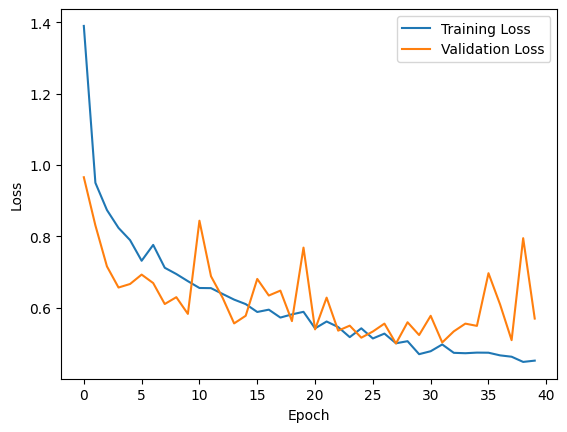

In [65]:
plt.plot(training_losses0, label='Training Loss')
plt.plot(valid_losses0, label='Validation Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.show()

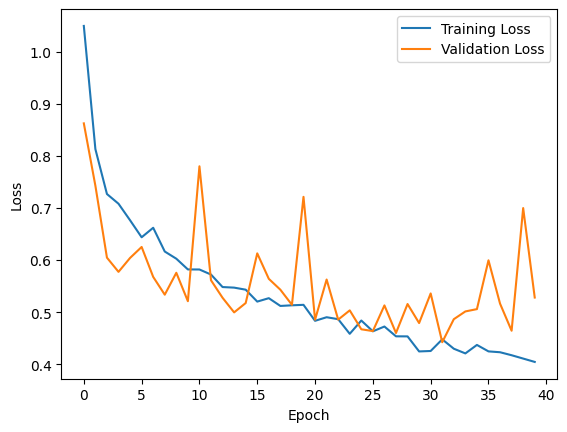

In [66]:
plt.plot(training_emo_losses0, label='Training Loss')
plt.plot(valid_emo_losses0, label='Validation Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.show()

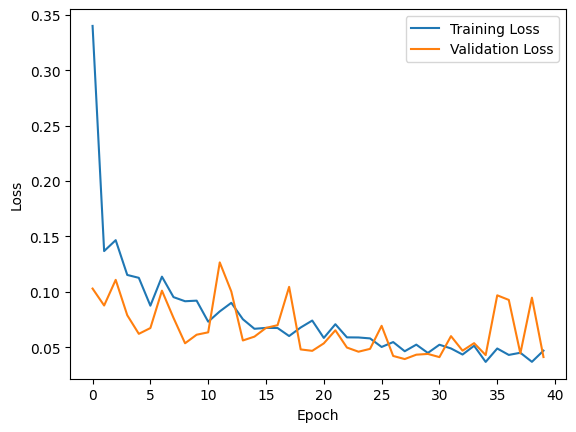

In [67]:
plt.plot(training_gender_losses0, label='Training Loss')
plt.plot(valid_gender_losses0, label='Validation Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.show()

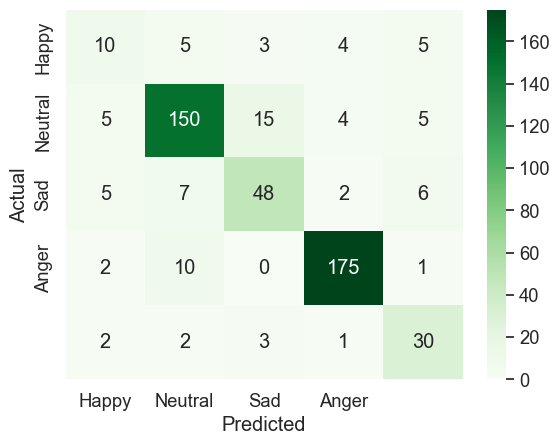

Testing finished with Loss:  0.46 | U_Accuracy:  0.73 | W_Accuracy:  0.83 | Precision:  0.83 | Recall:  0.83 | f1:  0.83
Accuracy per class:
Class 0: 0.37037037037037035
Class 1: 0.8379888268156425
Class 2: 0.7058823529411765
Class 3: 0.9308510638297872
Class 4: 0.7894736842105263


In [71]:
whisper_tiny.load_state_dict(torch.load('whisper_tiny_shemo_gender.bin'))
test(whisper_tiny, torch.nn.CrossEntropyLoss(), val_loader)